# Deep Learning-Based Waste Classification for Automated Recycling Sorting

**Module Name:** M507 Methods of Prediction  
**Student Name:** Varsha Babu  
**Student ID (GH No.):** GH1048862  


## 1. Problem Statement

Recycling facilities typically rely on manual labor to sort incoming waste into material categories such as plastic, metal, glass, and paper before it can be processed or sold to recycling buyers. This manual approach is slow, labor-intensive, and prone to human error and fatigue, which can lead to material misclassification. Misclassified or contaminated recycling streams may be rejected by buyers or downgraded in value, resulting in financial losses and reducing the environmental benefits of recycling.

As a data scientist at a recycling company (referred to here as **GreenSort Recycling**), I have been asked to explore whether a computer vision system could automate material classification at the point of sorting, reducing reliance on manual labor and improving consistency.

**Business benefit:** Automating classification could increase sorting throughput, reduce labor costs, and improve the purity of recycling streams. This could increase the value of processed recyclable materials and reduce contamination sent to landfill.

**Data collection:** In a real deployment, cameras could be mounted above the sorting line to photograph each item as it passes through the system. Images could then be labelled according to material type using existing sorting records or manual annotation. For this project, the publicly available RealWaste dataset is used as a proxy for this type of image-based sorting data. The dataset contains 4,752 images across 9 material categories.

**Dataset Source:** https://www.kaggle.com/datasets/joebeachcapital/realwaste

**ML formulation:** This is formulated as a multi-class image classification problem. Given an image of a single waste item, the model predicts which of the 9 material categories it belongs to: Cardboard, Food Organics, Glass, Metal, Miscellaneous Trash, Paper, Plastic, Textile Trash, or Vegetation. The predicted category could then be used to route the item to the appropriate downstream sorting bin.

## 2. Dataset Description

The **RealWaste** dataset is an image dataset designed for waste-material classification. It contains **4,752 images** belonging to **9 waste categories**. Each category is represented by a separate folder, allowing the folder names to be used as class labels during image classification.

The nine classes are:

- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation

The dataset is suitable for this project because the proposed business problem is to classify waste materials from images. The image-based structure allows a convolutional neural network or a transfer-learning-based neural network to learn visual patterns associated with different material categories.


## 3. Dataset Download and Setup

The RealWaste dataset is downloaded directly from Kaggle using the Kaggle API. The following cells install the required libraries, authenticate with a Kaggle API token, and download and extract the dataset into the working environment.

In [1]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q -U kaggle

import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

print("Kaggle API token configured.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.3 MB/s eta 0:00:00
Enter your Kaggle API token: ··········
Kaggle API token configured.


In [3]:
!kaggle datasets download -d joebeachcapital/realwaste

Dataset URL: https://www.kaggle.com/datasets/joebeachcapital/realwaste
License(s): Attribution 4.0 International (CC BY 4.0)
100% 657M/657M [00:37<00:00, 18.5MB/s]



In [4]:
!unzip -q realwaste.zip -d realwaste_data
print("Dataset extracted successfully.")

Dataset extracted successfully.


## 4. Data Exploration

Before building any models, it's important to understand the dataset's structure, quality, and class balance, since these factors directly influence preprocessing decisions and model evaluation. This section examines the folder structure, class distribution, sample images, and image quality of the RealWaste dataset.

In [6]:
data_root = Path("/content/realwaste_data/realwaste-main/RealWaste")

class_counts = {}
for class_dir in sorted(data_root.iterdir()):
    if class_dir.is_dir():
        n_images = len(list(class_dir.glob("*.jpg")))
        class_counts[class_dir.name] = n_images

counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Count"]
).sort_values("Count", ascending=False)

print(counts_df)
print("\nTotal images:", counts_df["Count"].sum())

                 Class  Count
6              Plastic    921
3                Metal    790
5                Paper    500
4  Miscellaneous Trash    495
0            Cardboard    461
8           Vegetation    436
2                Glass    420
1        Food Organics    411
7        Textile Trash    318

Total images: 4752


The output shows that **Plastic** has the highest number of images (921), followed by **Metal** (790), while **Textile Trash** has the fewest (318). The remaining classes range between 411 and 500 images. This indicates the dataset is **moderately imbalanced** - the largest class (Plastic) has roughly 2.9× as many images as the smallest class (Textile Trash). This imbalance will need to be addressed during preprocessing (e.g. via class weighting) and considered when choosing evaluation metrics, since accuracy alone could be misleading - macro-averaged metrics (e.g. macro F1) will give a fairer picture of performance across all classes, including the underrepresented ones.

/tmp/ipykernel_2133/3153715463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, x="Class", y="Count", palette="viridis")


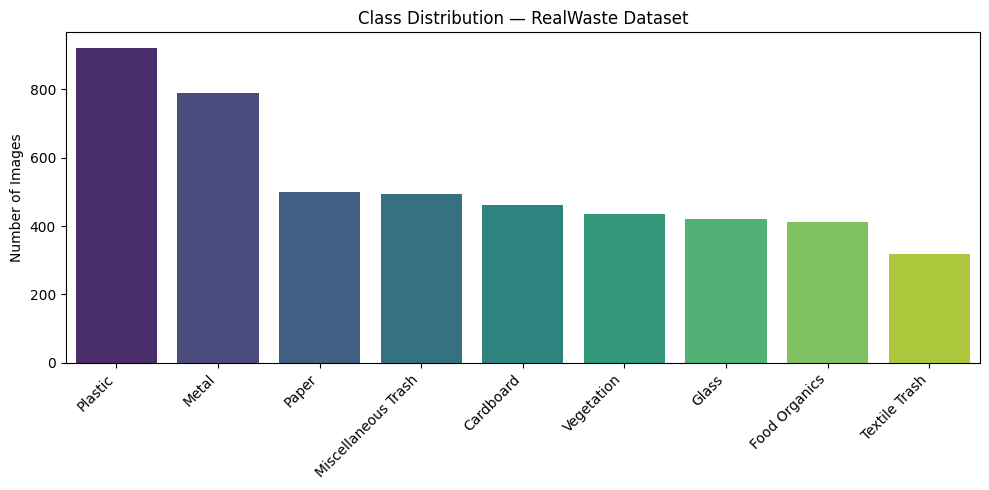

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=counts_df, x="Class", y="Count", palette="viridis")
plt.title("Class Distribution — RealWaste Dataset")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.xlabel("")
plt.tight_layout()
plt.show()

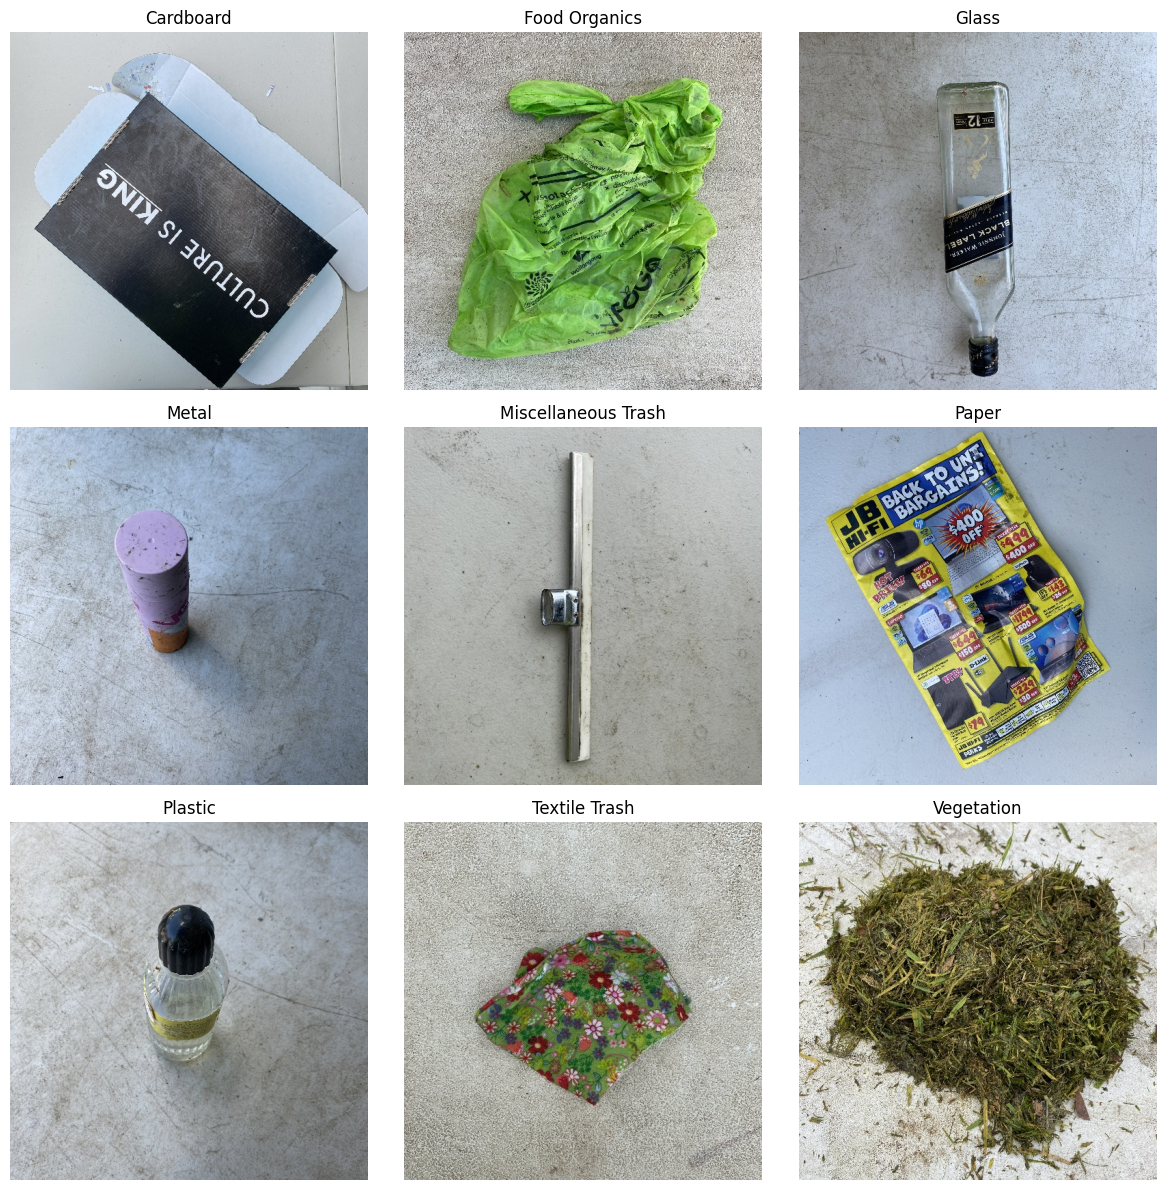

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, class_name in enumerate(sorted(class_counts.keys())):
    class_dir = data_root / class_name
    sample_img_path = list(class_dir.glob("*.jpg"))[0]
    img = plt.imread(sample_img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Sample Image Observations

The sampled images show that the classes generally contain a single, isolated waste item photographed against a consistent plain concrete-floor background, with minimal clutter or overlapping objects. This controlled setting is favourable for classification, since the model can learn to focus on the object itself rather than a cluttered background.

However, the controlled environment also means that the dataset may not fully represent messier real-world sorting conditions, such as multiple items overlapping on a moving conveyor belt, different camera angles, or variable lighting. This is an important consideration when interpreting the model's eventual performance and its potential deployment in an automated sorting environment.

In [9]:
from PIL import Image

sizes = set()
modes = set()
corrupt = []

for class_name in sorted(class_counts.keys()):
    for img_path in (data_root / class_name).glob("*.jpg"):
        try:
            with Image.open(img_path) as img:
                sizes.add(img.size)
                modes.add(img.mode)
        except Exception:
            corrupt.append(str(img_path))

print("Total images checked:", sum(class_counts.values()))
print("Unique image sizes:", sizes)
print("Image modes:", modes)
print("Corrupt/unreadable images:", len(corrupt))

Total images checked: 4752
Unique image sizes: {(524, 524)}
Image modes: {'RGB'}
Corrupt/unreadable images: 0


### Image Quality and Consistency

The check confirms that all **4,752 images** share the exact same resolution (524×524) and colour mode (RGB), with **zero corrupt or unreadable files**. This means the dataset requires no handling for inconsistent source dimensions or colour formats. The only resizing required will be to match the input size expected by the chosen model architecture, which will be applied uniformly during preprocessing.

## 5. Data Preprocessing and Feature Engineering

With the dataset explored, the next step is to prepare it for training: splitting it into train/validation/test sets, resizing and normalising images, and computing class weights to address the imbalance identified above. No manual feature engineering is required, since convolutional neural networks learn spatial features directly from raw pixel data.

In [10]:
!pip install -q split-folders

import splitfolders

splitfolders.ratio(
    str(data_root),
    output="realwaste_split",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

print("Split complete")

Copying files: 4752 files [00:03, 1196.42 files/s]

Split complete


In [11]:
split_root = Path("realwaste_split")

for subset in ["train", "val", "test"]:
    subset_dir = split_root / subset
    total = 0
    print(f"\n{subset.upper()}:")
    for class_dir in sorted(subset_dir.iterdir()):
        if class_dir.is_dir():
            n = len(list(class_dir.glob("*.jpg")))
            print(f"  {class_dir.name}: {n}")
            total += n
    print(f"  TOTAL: {total}")


TRAIN:
  Cardboard: 322
  Food Organics: 287
  Glass: 294
  Metal: 553
  Miscellaneous Trash: 346
  Paper: 350
  Plastic: 644
  Textile Trash: 222
  Vegetation: 305
  TOTAL: 3323

VAL:
  Cardboard: 69
  Food Organics: 61
  Glass: 63
  Metal: 118
  Miscellaneous Trash: 74
  Paper: 75
  Plastic: 138
  Textile Trash: 47
  Vegetation: 65
  TOTAL: 710

TEST:
  Cardboard: 70
  Food Organics: 63
  Glass: 63
  Metal: 119
  Miscellaneous Trash: 75
  Paper: 75
  Plastic: 139
  Textile Trash: 49
  Vegetation: 66
  TOTAL: 719


### Train, Validation and Test Split

The split totals confirm **3,323 training images**, **710 validation images**, and **719 test images** (3,323 + 710 + 719 = 4,752), matching the intended 70/15/15 split. Class proportions are preserved across all three sets. For example, **Plastic** remains the largest class (644 train / 138 validation / 139 test), while **Textile Trash** remains the smallest (222 train / 47 validation / 49 test).

Maintaining similar class proportions across the training, validation, and test sets helps make the validation and test results more representative of the data used for training. The remaining difference in class sizes will therefore be considered when evaluating model performance.

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    split_root / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    split_root / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    split_root / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=42
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 3323 files belonging to 9 classes.
Found 710 files belonging to 9 classes.
Found 719 files belonging to 9 classes.
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets normalized and optimized")

Datasets normalized and optimized


In [15]:
from sklearn.utils.class_weight import compute_class_weight

train_dir = split_root / "train"
train_labels = []
for idx, class_name in enumerate(class_names):
    n_images = len(list((train_dir / class_name).glob("*.jpg")))
    train_labels.extend([idx] * n_images)

train_labels = np.array(train_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_array))
print("Class weights:")
for idx, class_name in enumerate(class_names):
    print(f"  {class_name}: {class_weights[idx]:.3f}")

Class weights:
  Cardboard: 1.147
  Food Organics: 1.286
  Glass: 1.256
  Metal: 0.668
  Miscellaneous Trash: 1.067
  Paper: 1.055
  Plastic: 0.573
  Textile Trash: 1.663
  Vegetation: 1.211


As expected from the class distribution seen earlier, **Textile Trash** receives the highest weight (1.663) since it is the smallest class, while **Plastic** receives the lowest weight (0.573) as the largest class. **Metal**, the second-largest class, also receives a below-average weight (0.668). The remaining classes cluster around a weight of ~1.0–1.3, roughly proportional to their distance from the average class size. These weights will be applied during training in later experiments (via the `class_weight` argument) to penalise misclassification of minority classes more heavily, reducing the model's bias toward the majority classes (Plastic and Metal).

## 6. Model Training and Experimentation

This section evaluates different machine learning pipeline configurations for the waste classification problem. The experiments vary important modelling choices such as network architecture, regularisation, batch normalisation, data augmentation, class weighting, and transfer learning.

The validation results from the experiments are compared to identify the configuration selected for the final model. In accordance with the assessment requirements, the experiment results are reported in a comparison table without repeating the training code for each configuration.

The complete implementation is provided only for the selected final model, which is then evaluated on the unseen test dataset.

### 6.1 Experiment Comparison

The following table summarises the validation performance obtained from the completed experiments. The configurations vary important modelling choices such as network architecture, regularisation, batch normalisation, data augmentation, class weighting, early stopping, and transfer learning.

| Configuration | Validation Accuracy | Validation Loss |
|---|---:|---:|
| Baseline CNN | 62.82% | 2.5303 |
| CNN + Dropout (0.5) | 63.24% | 1.1493 |
| CNN + Batch Normalisation | 27.04% | 2.0349 |
| Batch Normalisation + Dropout | 64.51% | 1.1859 |
| Batch Normalisation + Dropout + Strong Augmentation | 55.21% | 1.3440 |
| Batch Normalisation + Dropout + Light Augmentation | 56.06% | 1.2295 |
| Batch Normalisation + Dropout + Class Weights | 65.49% | 1.1892 |
| Light Augmentation + Batch Normalisation + Dropout + Class Weights | 59.72% | 1.4024 |
| Batch Normalisation + Dropout + Class Weights + Early Stopping | 65.77% | 1.0797 |
| **MobileNetV2 Transfer Learning + Class Weights** | **75.92%** | **0.7088** |

The experiments show that different modelling and training strategies produced substantially different validation performance. The MobileNetV2 transfer-learning configuration achieved a validation accuracy of **75.92%** and a validation loss of **0.7088** in the final reproduced run.

This configuration was selected as the final model because it uses a pretrained MobileNetV2 feature extractor with a task-specific classification head and class weighting to account for differences in class frequency. The trained model is evaluated further on the unseen test dataset in the following section.

Accuracy and loss were used to compare configurations during experimentation for simplicity and consistency across the ten runs; macro F1 was reserved for the final model's assessment on the held-out test set, where class-level performance differences matter most.

In [18]:
num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 9


In [56]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model_final = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    # Note: images were rescaled to [0,1] during dataset preprocessing;
    # multiplying by 255 here restores the [0,255] range that
    # MobileNetV2's preprocess_input expects before it applies its
    # own internal scaling to [-1, 1].
    tf.keras.layers.Lambda(
        lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x * 255)
    ),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_final.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
history_final = model_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 64s 347ms/step - accuracy: 0.2296 - loss: 2.1897 - val_accuracy: 0.4690 - val_loss: 1.6247
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.4243 - loss: 1.5777 - val_accuracy: 0.6014 - val_loss: 1.2452
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5125 - loss: 1.3269 - val_accuracy: 0.6817 - val_loss: 1.0593
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5817 - loss: 1.1209 - val_accuracy: 0.7000 - val_loss: 0.9599
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6410 - loss: 0.9994 - val_accuracy: 0.7028 - val_loss: 0.8722
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6602 - loss: 0.9415 - val_accuracy: 0.7324 - val_loss: 0.8195
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6903 - loss: 0.8544 - val_accuracy: 0.7338 - val_loss: 0.7852
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6952 - loss: 0.8150 - val_a

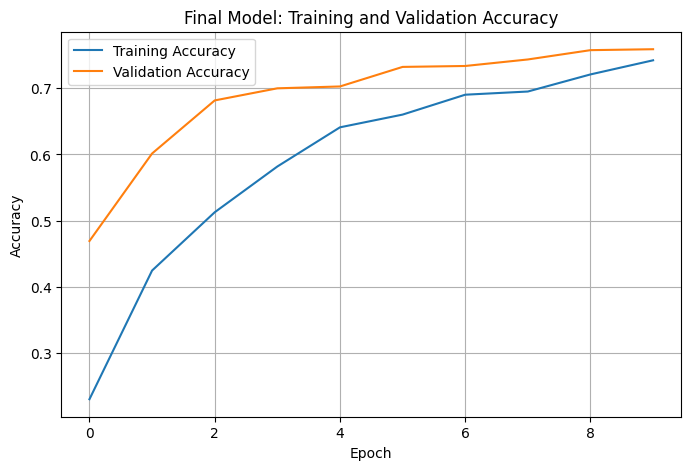

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(history_final.history["accuracy"], label="Training Accuracy")
plt.plot(history_final.history["val_accuracy"], label="Validation Accuracy")

plt.title("Final Model: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

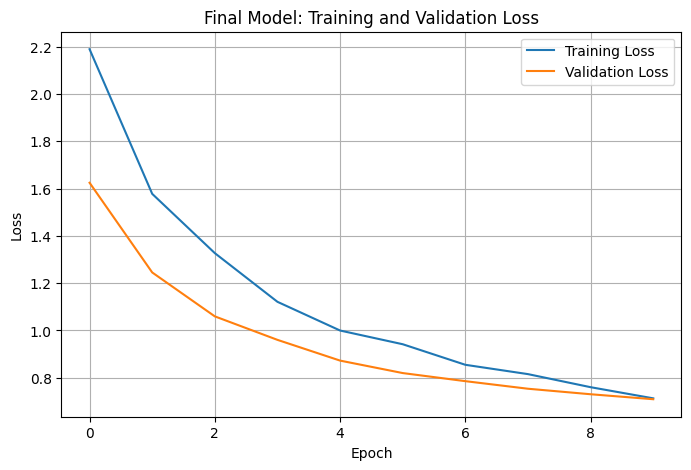

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history_final.history["loss"], label="Training Loss")
plt.plot(history_final.history["val_loss"], label="Validation Loss")

plt.title("Final Model: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

### 6.2 Training Performance

The training curves show consistent improvement across the 10 epochs. Training accuracy increased from 22.96% to 74.24%, while validation accuracy increased from 46.90% to 75.92%. At the same time, training loss decreased from 2.1897 to 0.7125, and validation loss decreased from 1.6247 to 0.7088.

The validation accuracy being higher than training accuracy in this run may be related to the use of class weights and the behaviour of the training process. Therefore, the final performance should be assessed using the separate unseen test dataset rather than relying only on the validation results.

In [23]:
test_loss, test_accuracy = model_final.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 591ms/step - accuracy: 0.7677 - loss: 0.6870
Test Accuracy: 0.7677
Test Loss: 0.6870


### 6.3 Unseen Test Evaluation

The final model was evaluated on **719 unseen test images** and achieved **76.77% accuracy** with a **test loss of 0.6870**.

The test accuracy was slightly higher than the validation accuracy of **75.92%**, showing similar performance on unseen data. Class-level evaluation is examined next to identify differences between waste categories.

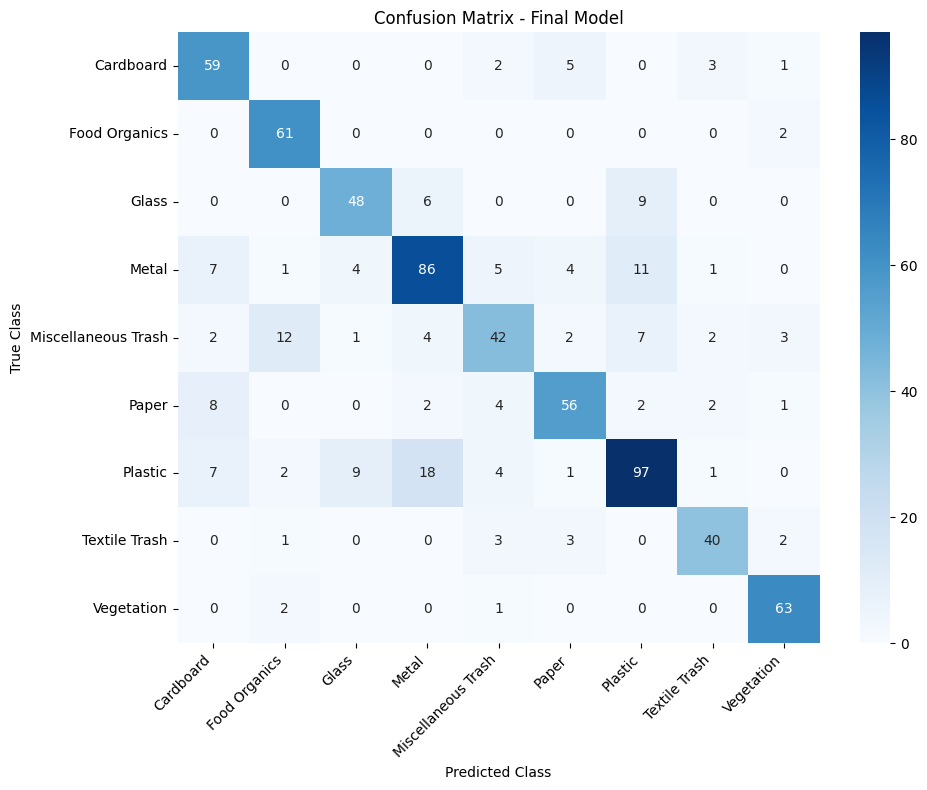

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_final.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

Classification Report:

                     precision    recall  f1-score   support

          Cardboard     0.7108    0.8429    0.7712        70
      Food Organics     0.7722    0.9683    0.8592        63
              Glass     0.7742    0.7619    0.7680        63
              Metal     0.7414    0.7227    0.7319       119
Miscellaneous Trash     0.6885    0.5600    0.6176        75
              Paper     0.7887    0.7467    0.7671        75
            Plastic     0.7698    0.6978    0.7321       139
      Textile Trash     0.8163    0.8163    0.8163        49
         Vegetation     0.8750    0.9545    0.9130        66

           accuracy                         0.7677       719
          macro avg     0.7708    0.7857    0.7752       719
       weighted avg     0.7663    0.7677    0.7642       719



### 6.4 Class-Level Performance

The model achieved **76.77% test accuracy** and a **macro-average F1-score of 0.7752**. Performance varied across the nine classes.

**Vegetation** achieved the highest F1-score (**0.9130**), while **Miscellaneous Trash** was the most difficult class, with an F1-score of **0.6176** and recall of **0.5600**.

These results show that overall accuracy does not capture differences between classes. The weaker performance on Miscellaneous Trash indicates that its varied visual characteristics make classification more challenging.

## 6.5 Model Explainability with Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping) is used to visualise the image regions that contribute to the final model's prediction. This provides a qualitative explanation of the MobileNetV2 model and helps assess whether it focuses on relevant parts of the waste item. One correctly classified and one incorrectly classified test image are examined.

In [51]:
gradcam_features = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer("Conv_1").output,
        base_model.output
    ]
)

print("Grad-CAM feature model ready.")

Grad-CAM feature model ready.


In [52]:
def generate_gradcam(img_array):

    processed_img = tf.keras.applications.mobilenet_v2.preprocess_input(
        img_array * 255.0
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = gradcam_features(
            processed_img, training=False
        )
        tape.watch(conv_outputs)

        x = model_final.get_layer("global_average_pooling2d_2")(features)
        x = model_final.get_layer("dense_2")(x)
        x = model_final.get_layer("dropout_2")(x, training=False)
        predictions = model_final.get_layer("dense_3")(x)

        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    gradients = tape.gradient(class_score, conv_outputs)

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()

    return heatmap.numpy(), predicted_class.numpy()

In [53]:
for images, labels in test_ds:
    predictions = model_final.predict(images, verbose=0)

    true_classes = np.argmax(labels.numpy(), axis=1)
    predicted_classes = np.argmax(predictions, axis=1)

    correct_indices = np.where(
        true_classes == predicted_classes
    )[0]

    if len(correct_indices) > 0:
        idx = correct_indices[0]
        correct_image = images[idx:idx+1]
        correct_true_class = true_classes[idx]
        correct_predicted_class = predicted_classes[idx]
        break

correct_heatmap, _ = generate_gradcam(correct_image)

print("True class:", class_names[correct_true_class])
print("Predicted class:", class_names[correct_predicted_class])

True class: Plastic
Predicted class: Plastic


In [54]:
for images, labels in test_ds:
    predictions = model_final.predict(images, verbose=0)

    true_classes = np.argmax(labels.numpy(), axis=1)
    predicted_classes = np.argmax(predictions, axis=1)

    wrong_indices = np.where(
        true_classes != predicted_classes
    )[0]

    if len(wrong_indices) > 0:
        idx = wrong_indices[0]
        wrong_image = images[idx:idx+1]
        wrong_true_class = true_classes[idx]
        wrong_predicted_class = predicted_classes[idx]
        break

wrong_heatmap, _ = generate_gradcam(wrong_image)

print("True class:", class_names[wrong_true_class])
print("Predicted class:", class_names[wrong_predicted_class])

True class: Metal
Predicted class: Cardboard


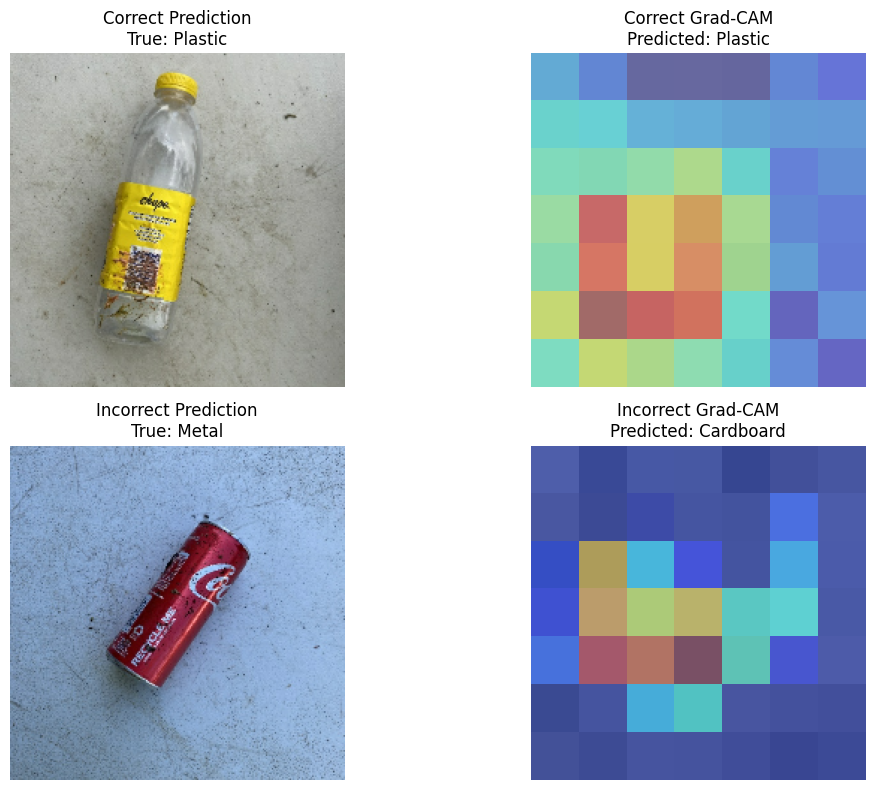

In [55]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(correct_image[0].numpy())
plt.title(
    f"Correct Prediction\nTrue: {class_names[correct_true_class]}"
)
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(correct_image[0].numpy())
plt.imshow(correct_heatmap, cmap="jet", alpha=0.45)
plt.title(
    f"Correct Grad-CAM\nPredicted: {class_names[correct_predicted_class]}"
)
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(wrong_image[0].numpy())
plt.title(
    f"Incorrect Prediction\nTrue: {class_names[wrong_true_class]}"
)
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(wrong_image[0].numpy())
plt.imshow(wrong_heatmap, cmap="jet", alpha=0.45)
plt.title(
    f"Incorrect Grad-CAM\nPredicted: {class_names[wrong_predicted_class]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

### Grad-CAM Interpretation

The correctly classified **Plastic** image shows activation concentrated around the bottle, indicating that the model focused on relevant object features.

For the incorrectly classified **Metal** image, the model predicted **Cardboard**. The activation is still concentrated around the waste item, but the model did not distinguish the metal can correctly.

Grad-CAM therefore provides a qualitative explanation of both correct and incorrect predictions.

## 7. Final Discussion and Business Recommendations

### Overall Findings

After comparing ten configurations, MobileNetV2 transfer learning with class weights was selected as the final model. It achieved **75.92% validation accuracy** with a validation loss of **0.7088**. On the unseen test set, it achieved **76.77% accuracy**, **0.6870 test loss**, and a **macro F1-score of 0.7752**.

### Business Implications

The results indicate that image classification could support automated waste sorting. A camera-based system could classify waste items before they are directed to the appropriate recycling or disposal stream. This could reduce manual sorting effort and improve sorting consistency and throughput. However, the current model should be treated as a prototype rather than a production-ready system.

### Strengths and Limitations

The pipeline includes data exploration, preprocessing, class weighting, ten model configurations, transfer learning, independent test evaluation and Grad-CAM explainability. Class-level evaluation also identifies weaknesses that overall accuracy alone would not show.

The main limitation is the controlled nature of the dataset. Images generally contain isolated objects with relatively consistent backgrounds, while real sorting environments may include overlapping objects, clutter, different viewpoints and variable lighting. Performance also varies between classes. **Vegetation** achieved the highest F1-score (**0.9130**), while **Miscellaneous Trash** was the weakest (**0.6176**).

### Recommendations

Future work should include more diverse real-world images and data collected from conveyor-belt environments. Additional transfer-learning architectures could be compared, while targeted augmentation and investigation of commonly confused classes may improve performance. The model should also be tested under realistic operating conditions before deployment.

### Explainability and Deployment

Grad-CAM provides a qualitative explanation by showing the image regions contributing to the model's predictions. The analysed examples show that the model focuses mainly on the waste objects, although relevant attention does not always result in a correct prediction.

Overall, the model demonstrates useful potential for automated waste classification, but further data collection, validation and real-world testing are required before deployment.

## 8. References

Arvidsson, J. (n.d.) *RealWaste Image Classification*. Kaggle. Available at: https://www.kaggle.com/datasets/joebeachcapital/realwaste (Accessed: 17 September 2026).

TensorFlow (2024) *tf.keras.applications.MobileNetV2*. Available at: https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2 (Accessed: 17 September 2026).

TensorFlow (2024) *tf.keras.utils.image_dataset_from_directory*. Available at: https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory (Accessed: 17 September 2026).

TensorFlow (2024) *Load and preprocess images*. Available at: https://www.tensorflow.org/tutorials/load_data/images (Accessed: 17 September 2026).

Scikit-learn (2026) *sklearn.metrics: Classification metrics*. Available at: https://scikit-learn.org/stable/api/sklearn.metrics.html (Accessed: 17 September 2026).

Sandler, M., Howard, A., Zhu, M., Zhmoginov, A. and Chen, L.-C. (2018) ‘MobileNetV2: Inverted Residuals and Linear Bottlenecks’, *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, pp. 4510–4520.